In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Görüntü Sıkıştırma

Bu görevde **görüntüleri** 🖼️ veri olarak kullanacağız.

Görüntü sıkıştırma için **K-means** kullanarak, bir görüntüdeki renkleri yalnızca en sık kullanılanlara indirgeyeceksiniz.

## 1) Python ile görüntüler

Bu bölüm, Python'da görüntüleri nasıl işlediğimizi anlamanıza yardımcı olacaktır.  

**1. bölüm için kodlama gerekmez, dikkatlice okuyun ve verilen örnekleri uygulayın.**

### 1.1) Siyah beyaz görüntüler

Bir görüntü, her bir öğesinin bir piksel olduğu bir matris olarak tanımlanabilir.  

Renk skalası 0 (siyah) ile 255 (beyaz) arasındadır.  

Böylece, matristeki her bir öğenin değeri 0 ile 255 arasında olacaktır.

<img src="https://miro.medium.com/max/1386/1*bV7S0zACdidh11ikjYpLpQ.png">

Biz “matris” dedik, siz “numpy” düşündünüz, doğru 🙂  

👇 Aşağıdaki hücreyi çalıştırarak, yalnızca “numpy” ile oluşturulmuş siyah beyaz bir görüntüyü görebilirsiniz.

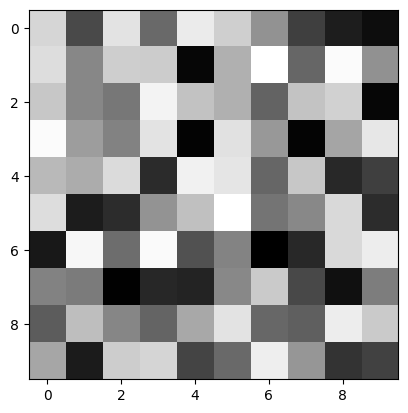

In [3]:
# 0 ile 255 arasında bir değere sahip 100 elemanlı bir vektör oluşturalım.
image_bw = np.random.uniform(low=0, high=255, size=100)

# Kare matris şeklinde yeniden şekillendirin, 10x10 piksel boyutunda bir görüntü elde ederiz.
image_bw = image_bw.reshape((10, 10))

# Son olarak oluşturulan görüntüyü göster
plt.imshow(image_bw, cmap='gray');

### 1.2) Renkli görüntüler :

Her renk, ana renklerin doğrusal bir kombinasyonudur: Kırmızı, Yeşil, Mavi  

Renkli bir görüntü, her bir ana renk için birer tane olmak üzere üç katmanın üst üste bindirilmesinden oluşur.  

Dolayısıyla her piksel için üç değerimiz vardır (Kırmızı, Yeşil, Mavi).

<img src="https://miro.medium.com/max/840/1*y0nV4cWk3KbzXSe9dIWL5g.jpeg">

👇  Yine, yalnızca `numpy` ile oluşturulmuş renkli bir görüntü görmek için aşağıdaki hücreleri çalıştırın.

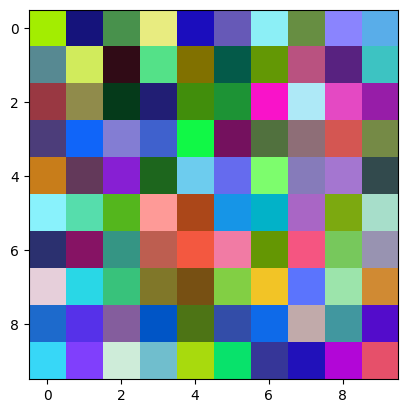

In [4]:
# 0 ile 1 arasında bir değere sahip 100*3 elemanlı bir vektör oluşturalım.
image_c = np.random.uniform(low=0., high=1., size=100*3)

# 3 renkli, 10x10 piksel boyutunda kare şeklinde bir görüntüye dönüştürün.
image_c = image_c.reshape((10, 10, 3))

# Son olarak oluşturulan görüntüyü göster
plt.imshow(image_c);

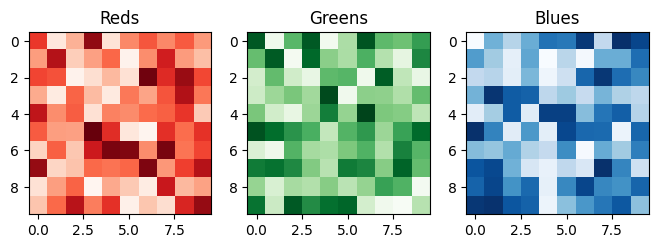

In [5]:
# Sezgisel bir fikir edinmek için, her renk katmanını çizelim.
fig, axs = plt.subplots(1, 3, figsize=(8, 6))
colors = {0:'Reds', 1:'Greens', 2:'Blues'}

for i in colors:
    axs[i].imshow(image_c[:, :, i], cmap=colors[i])
    axs[i].set_title(colors[i])

## 2) ML için görüntüler

### 2.1) Kurulum

`skimage` kütüphanesini yükleyin, bu bize klasik görüntülere erişim sağlayacaktır.

In [8]:
! pip install --quiet scikit-image


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


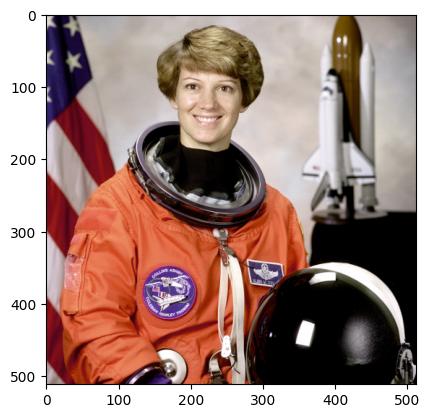

In [9]:
from skimage import data
img = data.astronaut()
plt.imshow(img);

❓ What is the shape of this image?  
Assign it to `img_shape`

In [10]:
img_shape = img.shape
print(img_shape)

(512, 512, 3)


### 2.2) Renk sayısı

Görüntümüzü sıkıştırmaya veya genel olarak makine öğrenimine hazır hale getirmek için, onu **gözlemler** ve **özellikler** olarak temsil etmemiz gerekir.  

Her **piksel** bir **gözlemdir**  
Her **renk değeri (Kırmızı, Yeşil, Mavi)** bir **özelliktir**  

Görüntümüzde **262.144 gözlem** (512 * 512 piksel) ve **3 özellik** (RGB) bulunmaktadır.

❓ Görüntüyü yeniden şekillendirin:  
- Mevcut 3 boyutlu şekli olan `width x height x 3`
- `n_piksel x 3` şeklindeki 2 boyutlu matrise, burada  `n_pixels = width * height`  

Yeniden şekillendirilen görüntüyü `X`'e atayın.

In [11]:
n_pixels = img.shape[0] * img.shape[1]
X = img.reshape((n_pixels, 3))

print(X.shape)

(262144, 3)


Renkli bir görüntü, 16 milyona kadar potansiyel renk içerebilir.  

Aslında, her piksel için **3** kanalımız vardır ve her kanal için **256** olası değerimiz vardır (0'dan 255'e kadar).  
Bu nedenle, renkli bir görüntüde potansiyel olarak maksimum **16.777.216** *($256^3$)* renk vardır.  

Görüntümüz sadece 262.144 piksel (512 * 512) olduğundan, her piksel üç kanalın değerleri tarafından tanımlanan tek bir renk içerdiğinden, en fazla 262.144 renk kullanır.

Hadi sayalım! 🕵️

❓ Bu resimdeki benzersiz renklerin sayısını `color_count` içinde saklayın.

In [12]:
import numpy as np
color_count = np.unique(X, axis=0).shape[0]

print(color_count)

113382


Elimizdekileri inceleyelim:
- 262.144 gözlem, her gözlem bir pikseldir
- Her gözlem için 3 özellik (Kırmızı, Yeşil ve Mavi değerleri)
- Bilinmeyen sayıda küme 😱

**Renk sayısını azaltmak için neler yapabileceğimize bakalım** 🎨

### 🧪 Kodunu Test Et

In [13]:
from nbresult import ChallengeResult

result = ChallengeResult('image_analysis',
                         img_shape = img_shape,
                         color_count = color_count)
result.write()
print(result.check())


============================= test session starts =============================
platform win32 -- Python 3.11.7, pytest-9.0.2, pluggy-1.6.0 -- C:\Users\meaki\AppData\Local\Programs\Python\Python311\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\meaki\AppData\Local\GitHubDesktop\app-3.5.4\S17D3-S-data-image-compressor\tests
plugins: anyio-4.12.0, dash-4.0.0
collecting ... collected 2 items

test_image_analysis.py::TestImageAnalysis::test_color_count PASSED       [ 50%]
test_image_analysis.py::TestImageAnalysis::test_img_shape PASSED         [100%]

============================== 2 passed in 0.02s ==============================


💯 You can commit your code:

git add tests/image_analysis.pickle

git commit -m 'Completed image_analysis step'

git push origin master



## 3) K-means ile sıkıştırma

**113.382** rengi **K** renge indirmek istiyoruz.  

Pikseller üzerinde `KMeans` algoritması kullanarak, her pikseli **K** kümeden birine atayabiliriz!  

Her kümenin merkezi, o kümeye ait piksellerin ortalama rengi olacaktır. 

Daha sonra bu “ortalama küme rengini” kümedeki her piksel için RGB değeri olarak kullanabiliriz.  

💪🧠 Haydi başlayalım, hedefimiz sadece **32** renk kullanmak!

❓ ML hazır görüntünüz `X` üzerinde `n_clusters=32` ile bir K-means uyarlayın ve bunu `kmeans`'e atayın.

In [14]:
from sklearn.cluster import KMeans

# 32 renk için KMeans
kmeans = KMeans(n_clusters=32, random_state=42)

kmeans.fit(X)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",32
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


👉 `kmeans`'inizin `labels_`'ini kontrol edin, ardından `shape` ve `number of unique values`'ını kontrol edin.

In [15]:
import numpy as np

labels = kmeans.labels_

print("Shape:", labels.shape)

unique_labels = np.unique(labels)
print("Number of unique clusters:", len(unique_labels))

Shape: (262144,)
Number of unique clusters: 32


☝️ Şöyle açıklayalım:

- Her etiket bir kümedir
- Her gözleme bir etiket atanmıştır
- Toplamda 32 farklı etiket vardır, her küme için bir tane

❓ `KMeans`'inizin `cluster_centers_` öğesini, şeklini ve ilk öğesini kontrol edin.

In [16]:
centers = kmeans.cluster_centers_
print("Shape of cluster centers:", centers.shape)
print("First cluster center:", centers[0])

Shape of cluster centers: (32, 3)
First cluster center: [236.53936348 230.98555276 234.33752094]


☝️Her cluster_center, RGB değerlerinin bir vektörüdür ve kümenin ortalama rengini temsil eder.

❓ Her piksel resmi için karşılık gelen kümenin ortalama rengini depolayan `X_compressed` dizisini oluşturun.

<details span="markdown">
    <summary>💡 Yardım</summary>

Bunu yalnızca `kmeans.cluster_centers_` ve `kmeans.labels_` kullanarak gerçekleştirebilirsiniz.

---

</details>

In [17]:
X_compressed = kmeans.cluster_centers_[kmeans.labels_]

print("Shape of compressed X:", X_compressed.shape)

Shape of compressed X: (262144, 3)


RGB değerleri tamsayı olmalıdır.  

`X_compressed` içindeki renklerimiz `float64` türündedir.  

❓ `X_compressed` türünü, 0 ile 255 arasında değişen, işaretsiz 8 bitlik tamsayı türü olan `uint8` türüne dönüştürün.

In [18]:
X_compressed = X_compressed.astype(np.uint8)


print("Dtype of X_compressed:", X_compressed.dtype)
print("Min/Max values:", X_compressed.min(), X_compressed.max())

Dtype of X_compressed: uint8
Min/Max values: 0 252


❓ Kullanılan benzersiz renk sayısının gerçekten 32 olduğunu doğrulayın.

In [19]:
unique_colors = np.unique(X_compressed, axis=0)
num_unique_colors = unique_colors.shape[0]

print("Number of unique colors:", num_unique_colors)

Number of unique colors: 32


Neredeyse bitti! 💪

## 4) Sıkıştırılmış görüntüyü çiz

`X_compressed` şeklimiz (262144, 3) olduğundan, bunu bir görüntü olarak görüntüleyemeyiz.

❓ Sıkıştırılmış görüntünüzü yeniden şekillendirin ve orijinal görüntünüzle yan yana çizim yapın.  

<details>
    <summary>💡 İpucu</summary>

Düzleştirilmiş `X_compressed` öğenizi bir görüntü için doğru boyutlara yeniden şekillendirmeniz gerekir.  
Orijinal görüntünüz bu boyutlara sahiptir.

---

</details>

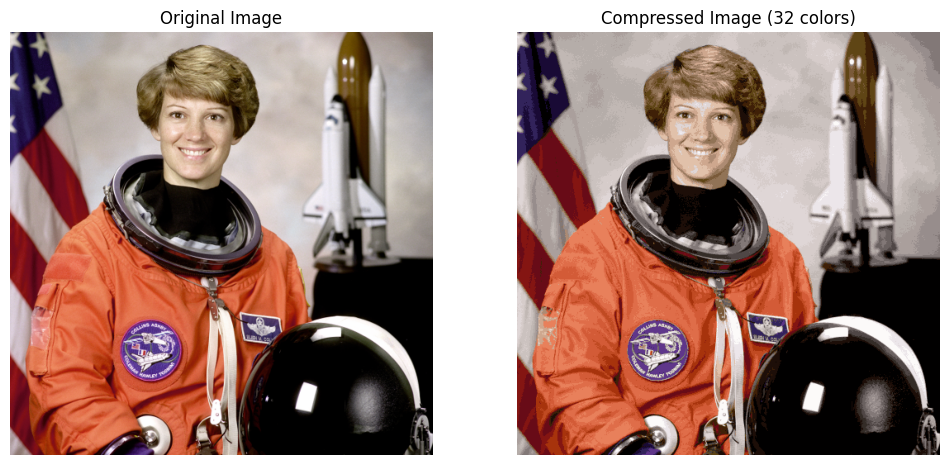

In [20]:
import matplotlib.pyplot as plt

height, width, channels = img.shape

img_compressed = X_compressed.reshape((height, width, channels))

plt.figure(figsize=(12,6))

# Orijinal
plt.subplot(1,2,1)
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")

# Sıkıştırılmış
plt.subplot(1,2,2)
plt.imshow(img_compressed)
plt.title("Compressed Image (32 colors)")
plt.axis("off")

plt.show()

Aferin! 💪

Bazı renkler kaybolmuş, ancak orijinal görüntüyü kolayca tanıyabilirsiniz.

🏁 **Not defterinizi itmeyi unutmayın.**  

Günün görevlerini yerine getirin ve zamanınız olursa buraya geri dönün 😉

## 5 - İsteğe bağlı) elbow yöntemini kullanın

En az renk bilgisini kaybeden optimum sıkıştırmayı bulmak için elbow yöntemini kullanmayı deneyebilirsiniz.   

Örneğin, [5, 10, 20, 30, 50, 70, 100] listesindeki `n_clusters` için `inertia` değerini çizmeye çalışın.  

⚠️ Uzun süren eğitim, birkaç dakika beklemeniz gerekebilir.

In [ ]:
# SENİN KODUN BURAYA

❓ Aşağıdaki hücreyi çalıştırarak, farklı sayıda küme kullanarak sıkıştırılmış görüntünüzü görselleştirin  
⚠️ Bu uzun bir eğitimdir, birkaç dakika beklemeniz gerekecektir

In [ ]:
wcss = []
compressed_astronaut = []
for i in [1, 2, 5, 10, 20, 30, 50, 70, 100]:
    print('working with ' + str(i) + ' clusters...', flush=True)
    kmeans = KMeans(n_clusters = i, max_iter=10)
    kmeans.fit(X)
    # inertia hesapla
    wcss.append(kmeans.inertia_)
    # sıkıştırılmış astronot hesapla
    labels = kmeans.labels_
    centers = kmeans.cluster_centers_
    X_compressed = centers[labels]
    X_compressed = X_compressed.astype('uint8')
    img_compressed = X_compressed.reshape(img_shape[0], img_shape[1], img_shape[2])
    compressed_astronaut.append(img_compressed)
    # print edin
    print("-"*120)
    print(f"If we compress our 113382 unique colors into {i} clusters...")
    print(f"The Kmeans inertia is equal to {kmeans.inertia_}")
    fig, ax = plt.subplots(1, 2, figsize = (7, 7))
    ax[0].imshow(img)
    ax[0].set_title('Original Image')
    ax[1].imshow(img_compressed)
    ax[1].set_title('Compressed Image')
    for ax in fig.axes:
        ax.axis('off')
    plt.tight_layout()
    plt.show()